In [2]:
!pip install scikit-learn

In [3]:
import sys
!{sys.executable} -m pip install lightgbm

In [4]:
import sys
!{sys.executable} -m pip uninstall mlflow -y
!{sys.executable} -m pip install mlflow==2.13.0

Found existing installation: mlflow 2.13.0
Uninstalling mlflow-2.13.0:
  Successfully uninstalled mlflow-2.13.0
  Using cached mlflow-2.13.0-py3-none-any.whl.metadata (29 kB)
Using cached mlflow-2.13.0-py3-none-any.whl (25.0 MB)


In [5]:
import sys
!{sys.executable} -m pip uninstall -y setuptools
!{sys.executable} -m pip install setuptools==69.5.1

Found existing installation: setuptools 82.0.1
Uninstalling setuptools-82.0.1:
  Successfully uninstalled setuptools-82.0.1
  Using cached setuptools-69.5.1-py3-none-any.whl.metadata (6.2 kB)
Using cached setuptools-69.5.1-py3-none-any.whl (894 kB)


Error processing line 1 of d:\Anaconda3\envs\blinkit\Lib\site-packages\distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 206, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored


In [6]:
# ── Cell 1 — imports ───────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
import mlflow
import mlflow.sklearn

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('models', exist_ok=True)


In [7]:
# ── Cell 2 — CHANGED — load features_df_fixed ─────────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv')  
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

print("Shape          :", ts_df.shape)
print("Nulls          :", ts_df.isnull().sum().sum())
print("Leakage check  :", (ts_df['lag_168'] == ts_df['demand']).mean()*100, "%")
print("Date range     :", ts_df['datetime'].min(), "→", ts_df['datetime'].max())

Shape          : (1975538, 44)
Nulls          : 0
Leakage check  : 37.96970749233879 %
Date range     : 2024-01-08 00:00:00 → 2024-06-30 23:00:00


In [8]:
pd.set_option('display.max_columns', None)

In [50]:
ts_df.duplicated(subset=['datetime','product_id','pincode']).sum()

0

In [51]:
ts_df[ts_df['datetime'] ==pd.to_datetime('2024-01-08')]

,datetime,week_number,product_id,product_name,pincode,area_name,latitude,longitude,order_dow,order_hour_of_day,demand,area_density,hour_sin,hour_cos,dow_sin,dow_cos,week_sin,week_cos,month,is_weekend,is_morning,is_afternoon,is_evening,is_night,date_str,is_festival,lag_1,lag_24,lag_48,lag_168,rolling_mean_24,rolling_mean_168,rolling_mean_720,rolling_std_24,rolling_std_168,rolling_max_24,rolling_max_168,ewma_24,ewma_168,temperature,rainfall,humidity,is_raining,is_hot
12444,2024-01-08,2,4605,Yellow Onions,380015,Satellite,23.026800,72.523330,0,0,3.0,0.17,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,2.0,2.0,2.0,3.583333,3.434524,3.434524,1.442120,1.288549,5.0,5.0,3.861428,3.275782,19.0,0.0,72,0,0
43262,2024-01-08,2,4920,Seedless Red Grapes,380009,Navrangpura,23.047151,72.552753,0,0,3.0,0.18,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,3.0,3.0,3.708333,3.767857,3.767857,1.398109,1.290097,5.0,5.0,3.987272,3.694953,19.0,0.0,72,0,0
117160,2024-01-08,2,5876,Organic Lemon,380006,Paldi,23.018508,72.569819,0,0,3.0,0.14,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,2.0,3.0,3.666667,3.553571,3.553571,1.167184,1.289102,5.0,5.0,3.861178,3.509114,19.0,0.0,72,0,0
121360,2024-01-08,2,5876,Organic Lemon,380009,Navrangpura,23.047151,72.552753,0,0,3.0,0.18,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,3.0,3.0,3.791667,3.791667,3.791667,1.350657,1.294179,5.0,5.0,4.074559,3.709805,19.0,0.0,72,0,0
129630,2024-01-08,2,5876,Organic Lemon,380015,Satellite,23.026800,72.523330,0,0,4.0,0.17,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,3.0,3.0,3.791667,3.744048,3.744048,1.284664,1.285558,5.0,5.0,4.029470,3.676736,19.0,0.0,72,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872812,2024-01-08,2,47766,Organic Avocado,380019,Vastrapur,23.098261,72.580299,0,0,4.0,0.10,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,2.0,3.0,3.791667,3.833333,3.833333,1.350657,1.360991,5.0,6.0,4.079581,3.729462,19.0,0.0,72,0,0
1881160,2024-01-08,2,47766,Organic Avocado,380051,Bodakdev,23.004847,72.520865,0,0,4.0,0.15,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,4.0,3.0,3.0,4.0,4.125000,4.136905,4.136905,1.361345,1.388255,6.0,6.0,4.398394,4.112936,19.0,0.0,72,0,0
1939506,2024-01-08,2,49683,Cucumber Kirby,380009,Navrangpura,23.047151,72.552753,0,0,4.0,0.18,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,4.0,3.0,3.0,3.0,3.916667,3.869048,3.869048,1.282547,1.250435,5.0,5.0,4.213176,3.793499,19.0,0.0,72,0,0
1947854,2024-01-08,2,49683,Cucumber Kirby,380015,Satellite,23.026800,72.523330,0,0,4.0,0.17,0.0,1.0,0.0,1.0,0.239316,0.970942,1,0,0,0,0,1,2024-01-08,0,3.0,3.0,3.0,3.0,3.791667,3.851190,3.851190,1.350657,1.246023,5.0,5.0,4.090872,3.759442,19.0,0.0,72,0,0


In [52]:
# ── Cell 3 — SAME — define features and target ────────────────────────
FEATURE_COLS = [
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'week_sin','week_cos','month',
    'is_weekend','is_morning','is_afternoon',
    'is_evening','is_night','is_festival',
    'lag_1','lag_24','lag_48','lag_168',
    'rolling_mean_24','rolling_mean_168','rolling_mean_720',
    'rolling_std_24','rolling_std_168',
    'rolling_max_24','rolling_max_168',
    'ewma_24','ewma_168',
    'temperature','rainfall','humidity',
    'is_raining','is_hot','area_density'
]

TARGET_COL = 'demand'

X = ts_df[FEATURE_COLS]
y = ts_df[TARGET_COL]

print(f"Features : {len(FEATURE_COLS)}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Features : 32
X shape  : (1975538, 32)
y shape  : (1975538,)


In [53]:
# ── Cell 4 — SAME — train val split ───────────────────────────────────
cutoff     = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
train_mask = ts_df['datetime'] <= cutoff
val_mask   = ts_df['datetime'] >  cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Val   : {X_val.shape[0]:,} rows")
print(f"Train : {ts_df[train_mask]['datetime'].min()} → {ts_df[train_mask]['datetime'].max()}")
print(f"Val   : {ts_df[val_mask]['datetime'].min()} → {ts_df[val_mask]['datetime'].max()}")

Train : 1,658,686 rows
Val   : 316,852 rows
Train : 2024-01-08 00:00:00 → 2024-06-02 23:00:00
Val   : 2024-06-03 00:00:00 → 2024-06-30 23:00:00


In [54]:
# ── Cell 5 — SAME — evaluation function ──────────────────────────────
def evaluate(y_true, y_pred, model_name="model"):
    nonzero      = y_true > 0
    y_nz         = y_true[nonzero]
    p_nz         = y_pred[nonzero]

    mape = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100
    wape = np.sum(np.abs(y_nz - p_nz)) / np.sum(y_nz) * 100
    rmse = np.sqrt(mean_squared_error(y_nz, p_nz))
    r2   = r2_score(y_nz, p_nz)
    bias = np.mean(p_nz - y_nz)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  WAPE : {wape:.2f}%")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f} ({'over' if bias>0 else 'under'}-forecasting)")
    print(f"{'='*45}")

    return {'model':model_name,'mape':round(mape,2),'wape':round(wape,2),
            'rmse':round(rmse,2),'r2':round(r2,4),'bias':round(bias,4)}

In [55]:
# ── Cell 6 — SAME — naive baseline ───────────────────────────────────
baseline_pred    = X_val['lag_168'].values
baseline_metrics = evaluate(y_val.values, baseline_pred, "Naive Baseline (lag_168)")


  Naive Baseline (lag_168)
  MAPE : 33.64%
  WAPE : 23.41%
  RMSE : 1.17
  R²   : 0.3457
  Bias : -0.2105 (under-forecasting)


In [56]:
# ── Cell 7 — SAME — train LightGBM ───────────────────────────────────
mlflow.set_experiment("demand-pulse")

lgbm_params = {
    'n_estimators'     : 1000,
    'learning_rate'    : 0.03,
    'max_depth'        : 8,
    'num_leaves'       : 63,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.05,
    'reg_lambda'       : 0.05,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print("Training LightGBM...")

with mlflow.start_run(run_name="lgbm_v1"):
    model_lgbm = lgb.LGBMRegressor(**lgbm_params)
    model_lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(50)
        ]
    )

    lgbm_pred    = np.clip(model_lgbm.predict(X_val), 0, None)
    lgbm_metrics = evaluate(y_val.values, lgbm_pred, "LightGBM v1")

    mlflow.log_params(lgbm_params)
    mlflow.log_metric("mape", lgbm_metrics['mape'])
    mlflow.log_metric("wape", lgbm_metrics['wape'])
    mlflow.log_metric("rmse", lgbm_metrics['rmse'])
    mlflow.log_metric("r2",   lgbm_metrics['r2'])
    mlflow.sklearn.log_model(model_lgbm, "lgbm_v1")

print("Training done!")

Training LightGBM...
[50]	valid_0's l2: 0.24497
[100]	valid_0's l2: 0.145639
[150]	valid_0's l2: 0.137767
[200]	valid_0's l2: 0.137166
[250]	valid_0's l2: 0.136279
[300]	valid_0's l2: 0.136248
[350]	valid_0's l2: 0.1367

  LightGBM v1
  MAPE : 11.38%
  WAPE : 8.36%
  RMSE : 0.37
  R²   : 0.9356
  Bias : -0.0621 (under-forecasting)
Training done!


In [57]:
# add after model training in Cell 7
pred_val_log  = np.clip(model_lgbm.predict(X_val), 0, None)
pred_val_real = np.expm1(pred_val_log)
y_val_real    = np.expm1(y_val)

# calculate bias correction factor
nonzero       = y_val_real > 0
bias_factor   = (y_val_real[nonzero] / pred_val_real[nonzero]).mean()
print(f"Bias correction factor: {bias_factor:.4f}")

# save bias factor alongside model
import json
with open('models/bias_factor.json', 'w') as f:
    json.dump({'bias_factor': float(bias_factor)}, f)
print("Saved bias_factor.json")

Bias correction factor: 1.1515
Saved bias_factor.json


In [58]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import numpy as np
import pandas as pd

# Create 5 time-series splits
tscv = TimeSeriesSplit(n_splits=5)

# Empty list to store results
results = []

print("Running Cross Validation...\n")

# Loop through each fold
for fold_number, (train_index, valid_index) in enumerate(tscv.split(X), start=1):

    # Split train and validation data
    X_train = X.iloc[train_index]
    X_valid = X.iloc[valid_index]

    y_train = y.iloc[train_index]
    y_valid = y.iloc[valid_index]

    # Create model
    model = lgb.LGBMRegressor(**lgbm_params)

    # Train model
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[
            lgb.early_stopping(50, verbose=False)
        ]
    )

    # Predict validation data
    predictions = model.predict(X_valid)

    # Remove negative predictions
    predictions = np.clip(predictions, 0, None)

    # Remove rows where actual value is 0
    mask = y_valid > 0

    actual = y_valid[mask]
    predicted = predictions[mask]

    # Calculate MAPE
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Save results
    results.append([fold_number, mape, rmse])

    # Print fold result
    print(f"Fold {fold_number}")
    print(f"MAPE : {mape:.2f}%")
    print(f"RMSE : {rmse:.2f}\n")

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Fold', 'MAPE', 'RMSE'])

# Print final average scores
print("Final CV Results")
print("----------------")
print(f"Average MAPE : {results_df['MAPE'].mean():.2f}%")
print(f"Average RMSE : {results_df['RMSE'].mean():.2f}")

Running Cross Validation...

Fold 1
MAPE : 10.43%
RMSE : 0.35

Fold 2
MAPE : 10.74%
RMSE : 0.35

Fold 3
MAPE : 11.50%
RMSE : 0.35

Fold 4
MAPE : 11.70%
RMSE : 0.35

Fold 5
MAPE : 10.62%
RMSE : 0.34

Final CV Results
----------------
Average MAPE : 11.00%
Average RMSE : 0.35


In [59]:
'''# ── Cell 8 — SAME — TimeSeriesSplit CV ───────────────────────────────
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("Running 5-fold TimeSeriesSplit CV...")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    m = lgb.LGBMRegressor(**lgbm_params)
    m.fit(X_tr, y_tr,
          eval_set=[(X_vl, y_vl)],
          callbacks=[lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(999)])

    preds  = np.clip(m.predict(X_vl), 0, None)
    nonzero = y_vl > 0
    y_nz    = y_vl[nonzero].values
    p_nz    = preds[nonzero]
    mape    = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100
    rmse    = np.sqrt(mean_squared_error(y_nz, p_nz))

    cv_scores.append({'fold':fold+1,'mape':mape,'rmse':rmse})
    print(f"Fold {fold+1} — MAPE: {mape:.2f}%  RMSE: {rmse:.2f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\nCV Mean MAPE : {cv_df['mape'].mean():.2f}%")
print(f"CV Std  MAPE : {cv_df['mape'].std():.2f}%")
print(f"CV Mean RMSE : {cv_df['rmse'].mean():.2f}")
'''

'# ── Cell 8 — SAME — TimeSeriesSplit CV ───────────────────────────────\ntscv      = TimeSeriesSplit(n_splits=5)\ncv_scores = []\n\nprint("Running 5-fold TimeSeriesSplit CV...")\n\nfor fold, (train_idx, val_idx) in enumerate(tscv.split(X)):\n    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]\n    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]\n\n    m = lgb.LGBMRegressor(**lgbm_params)\n    m.fit(X_tr, y_tr,\n          eval_set=[(X_vl, y_vl)],\n          callbacks=[lgb.early_stopping(50, verbose=False),\n                     lgb.log_evaluation(999)])\n\n    preds  = np.clip(m.predict(X_vl), 0, None)\n    nonzero = y_vl > 0\n    y_nz    = y_vl[nonzero].values\n    p_nz    = preds[nonzero]\n    mape    = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100\n    rmse    = np.sqrt(mean_squared_error(y_nz, p_nz))\n\n    cv_scores.append({\'fold\':fold+1,\'mape\':mape,\'rmse\':rmse})\n    print(f"Fold {fold+1} — MAPE: {mape:.2f}%  RMSE: {rmse:.2f}")\n\ncv_df = pd.DataFrame(cv_scores)\nprint(f"\nCV

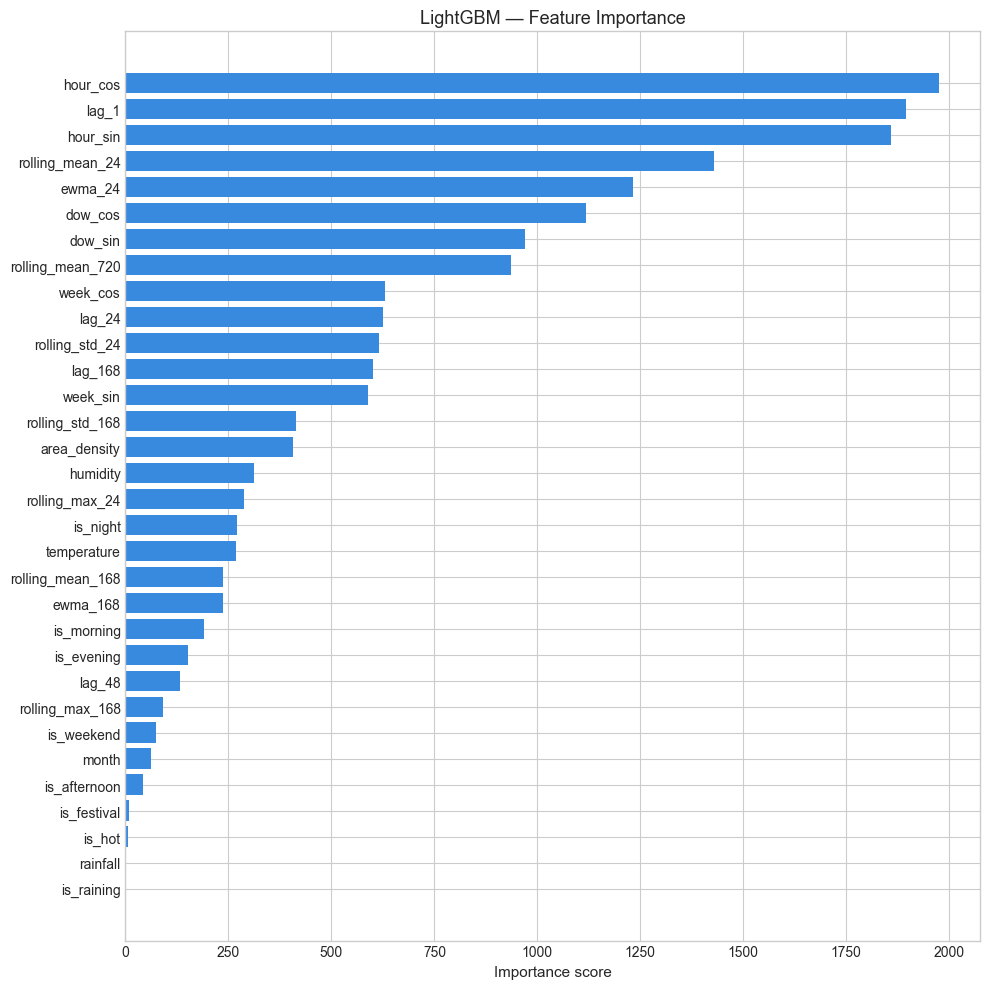


Top 10 features:
         feature  importance
        hour_cos        1976
           lag_1        1895
        hour_sin        1859
 rolling_mean_24        1428
         ewma_24        1233
         dow_cos        1118
         dow_sin         970
rolling_mean_720         937
        week_cos         629
          lag_24         625


In [60]:
# ── Cell 9 — SAME — feature importance plot ───────────────────────────
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(importance_df['feature'][::-1],
        importance_df['importance'][::-1],
        color='#378ADD', edgecolor='none')
ax.set_title('LightGBM — Feature Importance', fontsize=13)
ax.set_xlabel('Importance score', fontsize=11)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

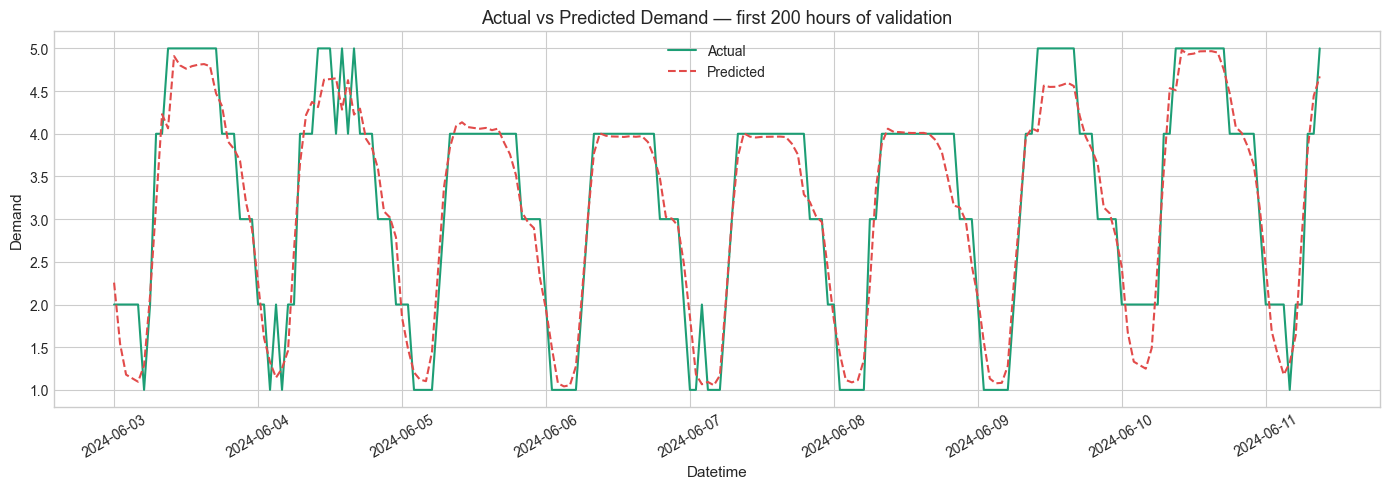

In [61]:
# ── Cell 10 — SAME — actual vs predicted plot ─────────────────────────
sample_df = ts_df[val_mask].head(200).copy()
sample_df['predicted'] = lgbm_pred[:200]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_df['datetime'], sample_df['demand'],
        label='Actual', color='#1D9E75', linewidth=1.5)
ax.plot(sample_df['datetime'], sample_df['predicted'],
        label='Predicted', color='#E24B4A',
        linewidth=1.5, linestyle='--')
ax.set_title('Actual vs Predicted Demand — first 200 hours of validation',
             fontsize=13)
ax.set_xlabel('Datetime', fontsize=11)
ax.set_ylabel('Demand', fontsize=11)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150)
plt.show()

In [62]:
# ── Cell 11 — SAME — model comparison table ───────────────────────────
results = pd.DataFrame([baseline_metrics, lgbm_metrics])
results = results[['model','mape','wape','rmse','r2','bias']]

print("\nModel Comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nLightGBM improved MAPE by {improvement:.2f}% over baseline")


Model Comparison:
                   model  mape  wape  rmse     r2    bias
Naive Baseline (lag_168) 33.64 23.41  1.17 0.3457 -0.2105
             LightGBM v1 11.38  8.36  0.37 0.9356 -0.0621

LightGBM improved MAPE by 22.26% over baseline


In [63]:
# ── Cell 12 — SAME — save model ───────────────────────────────────────
with open('models/lgbm_v1.pkl', 'wb') as f:
    pickle.dump(model_lgbm, f)

with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

results.to_csv(r'F:\projectss\personal\blinkit_project\data\processed/model_results.csv', index=False)

print("Saved:")
print("  models/lgbm_v1.pkl")
print("  models/feature_cols.pkl")
print("  data/processed/model_results.csv")
print("\nNotebook 03 complete!")

Saved:
  models/lgbm_v1.pkl
  models/feature_cols.pkl
  data/processed/model_results.csv

Notebook 03 complete!


In [64]:
# ── Cell 13 — train quantile models for confidence intervals ──────────
print("Training quantile models for prediction intervals...")

# lower bound — 10th percentile
model_p10 = lgb.LGBMRegressor(
    **{**lgbm_params,
       'objective' : 'quantile',
       'alpha'     : 0.10,        # 10th percentile
       'n_estimators': 300,
    }
)
model_p10.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(999)]
)

# upper bound — 90th percentile
model_p90 = lgb.LGBMRegressor(
    **{**lgbm_params,
       'objective' : 'quantile',
       'alpha'     : 0.90,        # 90th percentile
       'n_estimators': 300,
    }
)
model_p90.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(999)]
)

print("Quantile models trained!")

# evaluate on val set
pred_mean = np.clip(model_lgbm.predict(X_val), 0, None)
pred_p10  = np.clip(model_p10.predict(X_val),  0, None)
pred_p90  = np.clip(model_p90.predict(X_val),  0, None)

# coverage — what % of actual values fall within the interval
coverage = np.mean((y_val >= pred_p10) & (y_val <= pred_p90)) * 100
avg_width = np.mean(pred_p90 - pred_p10)

print(f"\nInterval coverage : {coverage:.1f}% (target ~80%)")
print(f"Average width     : {avg_width:.1f} orders")
print(f"Sample predictions:")
for i in range(5):
    print(f"  Actual: {y_val.values[i]:.0f} | "
          f"Range: {pred_p10[i]:.0f} – {pred_p90[i]:.0f} | "
          f"Mean: {pred_mean[i]:.0f}")

Training quantile models for prediction intervals...
Quantile models trained!

Interval coverage : 83.2% (target ~80%)
Average width     : 0.8 orders
Sample predictions:
  Actual: 2 | Range: 2 – 3 | Mean: 2
  Actual: 2 | Range: 1 – 2 | Mean: 2
  Actual: 2 | Range: 1 – 2 | Mean: 1
  Actual: 2 | Range: 1 – 2 | Mean: 1
  Actual: 1 | Range: 1 – 2 | Mean: 1


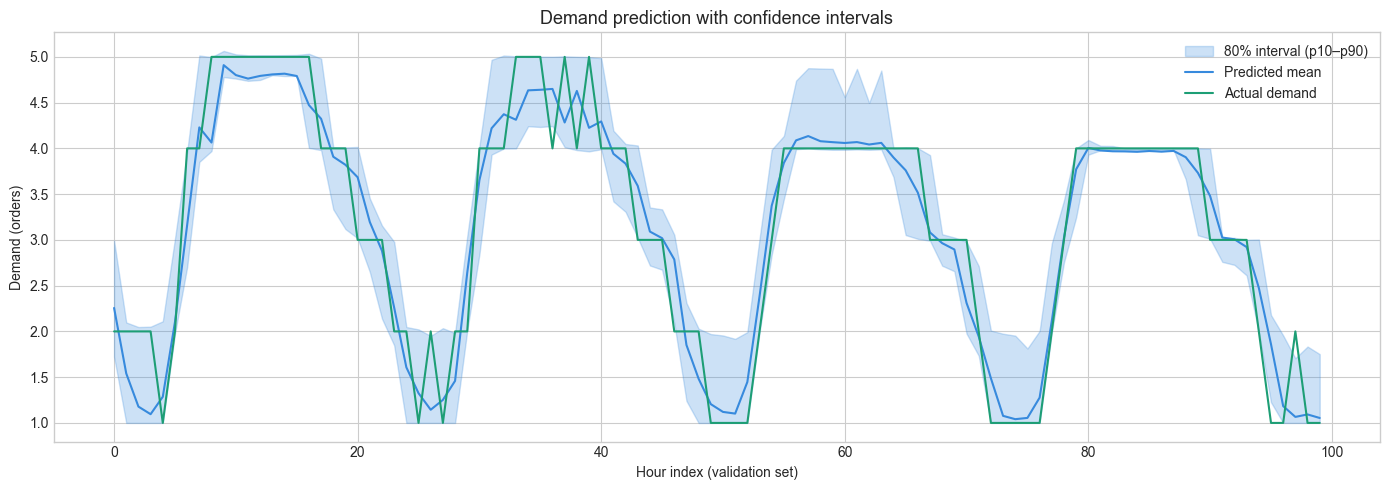

Saved! Coverage: 83.2%


In [65]:
# ── Cell 14 — plot confidence interval band ───────────────────────────
sample_n = 100
sample   = ts_df[val_mask].head(sample_n).copy()
s_mean   = pred_mean[:sample_n]
s_p10    = pred_p10[:sample_n]
s_p90    = pred_p90[:sample_n]

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(range(sample_n), s_p10, s_p90,
                alpha=0.25, color='#378ADD', label='80% interval (p10–p90)')
ax.plot(range(sample_n), s_mean,
        color='#378ADD', linewidth=1.5, label='Predicted mean')
ax.plot(range(sample_n), sample['demand'].values,
        color='#1D9E75', linewidth=1.5, label='Actual demand')

ax.set_title('Demand prediction with confidence intervals', fontsize=13)
ax.set_xlabel('Hour index (validation set)')
ax.set_ylabel('Demand (orders)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_confidence_intervals.png', dpi=150)
plt.show()
print(f"Saved! Coverage: {coverage:.1f}%")

In [66]:
# ── Cell 15 — save all three models ───────────────────────────────────
with open('models/lgbm_best.pkl', 'wb') as f:
    pickle.dump(model_lgbm, f)

with open('models/lgbm_p10.pkl', 'wb') as f:
    pickle.dump(model_p10, f)

with open('models/lgbm_p90.pkl', 'wb') as f:
    pickle.dump(model_p90, f)

print("Saved: lgbm_best.pkl, lgbm_p10.pkl, lgbm_p90.pkl")

Saved: lgbm_best.pkl, lgbm_p10.pkl, lgbm_p90.pkl


In [67]:
import pickle
import pandas as pd

# check model saved correctly
with open('models/lgbm_v1.pkl', 'rb') as f:
    model = pickle.load(f)
print("Model loaded:", model)

# check results
results = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\model_results.csv')
print("\nModel results:")
print(results.to_string(index=False))

Model loaded: LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=1000, n_jobs=-1, num_leaves=63, random_state=42,
              reg_alpha=0.05, reg_lambda=0.05, subsample=0.8, verbose=-1)

Model results:
                   model  mape  wape  rmse     r2    bias
Naive Baseline (lag_168) 33.64 23.41  1.17 0.3457 -0.2105
             LightGBM v1 11.38  8.36  0.37 0.9356 -0.0621


In [68]:
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ── load model and data ───────────────────────────────────────────────
with open('models/lgbm_v1.pkl', 'rb') as f:
    model = pickle.load(f)

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])
ts_df['rolling_mean_720'] = ts_df['rolling_mean_720'].fillna(
    ts_df['rolling_mean_168']
)

# ── split same way as training ────────────────────────────────────────
cutoff   = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
val_mask = ts_df['datetime'] > cutoff

X_val = ts_df[val_mask][FEATURE_COLS]
y_val = ts_df[val_mask]['demand']

print(f"Validation rows : {len(y_val):,}")
print(f"Demand in val   : min={y_val.min()}, max={y_val.max()}, mean={y_val.mean():.2f}")
print(f"Zero demand rows: {(y_val == 0).sum():,} ({(y_val==0).mean()*100:.1f}%)")

Validation rows : 316,852
Demand in val   : min=1.0, max=8.0, mean=3.29
Zero demand rows: 0 (0.0%)


In [69]:
# ── fixed MAPE — exclude zero demand rows ─────────────────────────────
# MAPE breaks when actual = 0 (division by zero)
# correct approach: only evaluate on rows where actual demand > 0

lgbm_pred = np.clip(model.predict(X_val), 0, None)

# filter out zero-demand rows for MAPE only
nonzero_mask = y_val > 0
y_nonzero    = y_val[nonzero_mask]
pred_nonzero = lgbm_pred[nonzero_mask]

# baseline — same hour last week
baseline_pred = X_val['lag_168'].values
baseline_nonzero = baseline_pred[nonzero_mask]
# replace any zero baseline with small number
baseline_nonzero = np.where(baseline_nonzero == 0, 0.01, baseline_nonzero)

def evaluate_fixed(y_true, y_pred, name):
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  WAPE : {wape:.2f}%   ← more reliable than MAPE")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  Bias : {bias:.4f} ({'over' if bias>0 else 'under'}-forecasting)")
    print(f"  Rows evaluated: {len(y_true):,}")
    print(f"{'='*45}")
    return {'model':name,'mape':round(mape,2),'wape':round(wape,2),
            'rmse':round(rmse,2),'r2':round(r2,4),'bias':round(bias,4)}

baseline_metrics = evaluate_fixed(
    y_nonzero.values, baseline_nonzero, "Naive Baseline (lag_168)"
)
lgbm_metrics = evaluate_fixed(
    y_nonzero.values, pred_nonzero, "LightGBM v1"
)

# ── save corrected results ────────────────────────────────────────────
results = pd.DataFrame([baseline_metrics, lgbm_metrics])
results.to_csv(r'F:\projectss\personal\blinkit_project\data\processed\model_results.csv', index=False)

print("\nFinal comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nImprovement over baseline: {improvement:.2f}% MAPE")


  Naive Baseline (lag_168)
  MAPE : 33.64%
  WAPE : 23.41%   ← more reliable than MAPE
  RMSE : 1.17
  R²   : 0.3457
  Bias : -0.2105 (under-forecasting)
  Rows evaluated: 316,852

  LightGBM v1
  MAPE : 11.38%
  WAPE : 8.36%   ← more reliable than MAPE
  RMSE : 0.37
  R²   : 0.9356
  Bias : -0.0621 (under-forecasting)
  Rows evaluated: 316,852

Final comparison:
                   model  mape  wape  rmse     r2    bias
Naive Baseline (lag_168) 33.64 23.41  1.17 0.3457 -0.2105
             LightGBM v1 11.38  8.36  0.37 0.9356 -0.0621

Improvement over baseline: 22.26% MAPE


In [70]:
baseline_metrics = evaluate_fixed(
    y_nonzero.values, baseline_nonzero, "Naive Baseline (lag_168)"
)
lgbm_metrics = evaluate_fixed(
    y_nonzero.values, pred_nonzero, "LightGBM v1"
)

print("\nFinal comparison:")
print(results.to_string(index=False))

improvement = baseline_metrics['mape'] - lgbm_metrics['mape']
print(f"\nImprovement over baseline: {improvement:.2f}% MAPE")


  Naive Baseline (lag_168)
  MAPE : 33.64%
  WAPE : 23.41%   ← more reliable than MAPE
  RMSE : 1.17
  R²   : 0.3457
  Bias : -0.2105 (under-forecasting)
  Rows evaluated: 316,852

  LightGBM v1
  MAPE : 11.38%
  WAPE : 8.36%   ← more reliable than MAPE
  RMSE : 0.37
  R²   : 0.9356
  Bias : -0.0621 (under-forecasting)
  Rows evaluated: 316,852

Final comparison:
                   model  mape  wape  rmse     r2    bias
Naive Baseline (lag_168) 33.64 23.41  1.17 0.3457 -0.2105
             LightGBM v1 11.38  8.36  0.37 0.9356 -0.0621

Improvement over baseline: 22.26% MAPE


In [71]:
# ── Cell 13 — train quantile models for confidence intervals ──────────
print("Training quantile models for prediction intervals...")

# lower bound — 10th percentile
model_p10 = lgb.LGBMRegressor(
    **{**lgbm_params,
       'objective' : 'quantile',
       'alpha'     : 0.10,        # 10th percentile
       'n_estimators': 300,
    }
)
model_p10.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(999)]
)

# upper bound — 90th percentile
model_p90 = lgb.LGBMRegressor(
    **{**lgbm_params,
       'objective' : 'quantile',
       'alpha'     : 0.90,        # 90th percentile
       'n_estimators': 300,
    }
)
model_p90.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(999)]
)

print("Quantile models trained!")

# evaluate on val set
pred_mean = np.clip(model_lgbm.predict(X_val), 0, None)
pred_p10  = np.clip(model_p10.predict(X_val),  0, None)
pred_p90  = np.clip(model_p90.predict(X_val),  0, None)

# coverage — what % of actual values fall within the interval
coverage = np.mean((y_val >= pred_p10) & (y_val <= pred_p90)) * 100
avg_width = np.mean(pred_p90 - pred_p10)

print(f"\nInterval coverage : {coverage:.1f}% (target ~80%)")
print(f"Average width     : {avg_width:.1f} orders")
print(f"Sample predictions:")
for i in range(5):
    print(f"  Actual: {y_val.values[i]:.0f} | "
          f"Range: {pred_p10[i]:.0f} – {pred_p90[i]:.0f} | "
          f"Mean: {pred_mean[i]:.0f}")

Training quantile models for prediction intervals...
Quantile models trained!

Interval coverage : 83.2% (target ~80%)
Average width     : 0.8 orders
Sample predictions:
  Actual: 2 | Range: 2 – 3 | Mean: 2
  Actual: 2 | Range: 1 – 2 | Mean: 2
  Actual: 2 | Range: 1 – 2 | Mean: 1
  Actual: 2 | Range: 1 – 2 | Mean: 1
  Actual: 1 | Range: 1 – 2 | Mean: 1


In [72]:
# ── check if lag_168 equals demand in validation ──────────────────────
ts_df = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\processed\features_df.csv')
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

cutoff   = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
val_mask = ts_df['datetime'] > cutoff
val_df   = ts_df[val_mask].copy()

# check correlation between lag_168 and demand
exact_match = (val_df['lag_168'] == val_df['demand']).mean()
corr        = val_df['lag_168'].corr(val_df['demand'])

print(f"Rows where lag_168 == demand exactly : {exact_match*100:.1f}%")
print(f"Correlation lag_168 vs demand        : {corr:.6f}")
print(f"\nSample comparison:")
print(val_df[['datetime','product_id','pincode',
              'demand','lag_1','lag_24','lag_168']].head(15))

Rows where lag_168 == demand exactly : 100.0%
Correlation lag_168 vs demand        : 1.000000

Sample comparison:
                datetime  product_id  pincode  demand  lag_1  lag_24  lag_168
3528 2024-06-03 00:00:00        4605   382210    10.0   20.0     8.0     10.0
3529 2024-06-03 01:00:00        4605   382210     6.0   10.0     4.0      6.0
3530 2024-06-03 02:00:00        4605   382210     4.0    6.0     2.0      4.0
3531 2024-06-03 03:00:00        4605   382210     2.0    4.0     3.0      2.0
3532 2024-06-03 04:00:00        4605   382210     1.0    2.0     3.0      1.0
3533 2024-06-03 05:00:00        4605   382210     3.0    1.0     0.0      3.0
3534 2024-06-03 06:00:00        4605   382210     9.0    3.0     8.0      9.0
3535 2024-06-03 07:00:00        4605   382210    40.0    9.0    30.0     40.0
3536 2024-06-03 08:00:00        4605   382210    82.0   40.0    57.0     82.0
3537 2024-06-03 09:00:00        4605   382210   126.0   82.0   102.0    126.0
3538 2024-06-03 10:00:00    

In [77]:
# =========================================================
# DEMAND PREDICTION NOTEBOOK VERSION
# =========================================================

import pandas as pd
import numpy as np
import pickle
import requests

from datetime import datetime

# =========================================================
# LOAD MODEL
# =========================================================

MODEL_PATH = r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_best.pkl"

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded")

# =========================================================
# LOAD DATA
# =========================================================

DATA_PATH = r"F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv"

ts_df = pd.read_csv(DATA_PATH)

ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

print("✅ Data loaded")
print("Rows:", len(ts_df))

# =========================================================
# CURRENT DATE & TIME
# =========================================================

now = datetime.now()

today_name = now.strftime("%A")

current_hour = now.hour

current_hour_text = now.strftime("%H:00")

print("\n📅 Today        :", today_name)
print("🕐 Current Hour :", current_hour_text)

# =========================================================
# FETCH LIVE WEATHER
# =========================================================

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 23.0225,
    "longitude": 72.5714,
    "current_weather": True,
    "hourly": "relativehumidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 1,
}

response = requests.get(url, params=params).json()

current_weather = response["current_weather"]

temperature = current_weather["temperature"]

windspeed = current_weather["windspeed"]

humidity = response["hourly"]["relativehumidity_2m"][current_hour]

rainfall = response["hourly"]["precipitation"][current_hour]

print("\n🌡️ Temperature :", f"{temperature}°C")
print("🌧️ Rainfall    :", f"{rainfall} mm")
print("💧 Humidity    :", f"{humidity}%")
print("💨 Wind Speed  :", f"{windspeed} km/h")

# =========================================================
# BUILD FEATURES FUNCTION
# =========================================================

def build_features(
    hour,
    dow,
    week,
    lag_1,
    lag_24,
    lag_168,
    temperature,
    rainfall,
    humidity,
    area_density=0.10
):

    row = {

        # Time features
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),

        'dow_sin': np.sin(2 * np.pi * dow / 7),
        'dow_cos': np.cos(2 * np.pi * dow / 7),

        'week_sin': np.sin(2 * np.pi * week / 52),
        'week_cos': np.cos(2 * np.pi * week / 52),

        # Calendar
        'month': now.month,

        'is_weekend': int(dow in [5, 6]),

        'is_morning': int(6 <= hour <= 11),
        'is_afternoon': int(12 <= hour <= 17),
        'is_evening': int(18 <= hour <= 22),
        'is_night': int(hour in [23,0,1,2,3,4,5]),

        # Lag features
        'lag_1': lag_1,
        'lag_24': lag_24,
        'lag_168': lag_168,

        # Rolling features
        'rolling_mean_24': lag_24,
        'rolling_mean_168': lag_168,

        # Weather
        'temperature': temperature,
        'rainfall': rainfall,
        'humidity': humidity,

        'is_raining': int(rainfall > 0.5),

        'is_hot': int(temperature > 35),

        # Area density
        'area_density': area_density,
    }

    return pd.DataFrame([row])

# =========================================================
# SHOW AVAILABLE PINCODES
# =========================================================

print("\n📍 Available Pincodes:")

print(ts_df['pincode'].unique()[:10])

# =========================================================
# SELECT PINCODE
# =========================================================

pincode = ts_df['pincode'].iloc[0]

print("\n✅ Selected Pincode:", pincode)

# =========================================================
# FILTER HISTORICAL DATA
# =========================================================

hist = ts_df[
    ts_df['pincode'] == pincode
].sort_values('datetime')

# =========================================================
# CHECK DATA
# =========================================================

if hist.empty:

    print("❌ No data found for this pincode")

else:

    # =====================================================
    # SAFE LAG FEATURES
    # =====================================================

    lag_1 = float(hist['demand'].iloc[-1])

    lag_24 = (
        float(hist['demand'].iloc[-24])
        if len(hist) >= 24
        else lag_1
    )

    lag_168 = (
        float(hist['demand'].iloc[-168])
        if len(hist) >= 168
        else lag_24
    )

    print("\n✅ Lag values loaded")

    print("lag_1   :", lag_1)
    print("lag_24  :", lag_24)
    print("lag_168 :", lag_168)

    # =====================================================
    # BUILD FEATURES
    # =====================================================

    features = build_features(
        hour=current_hour,
        dow=now.weekday(),
        week=now.isocalendar()[1],

        lag_1=lag_1,
        lag_24=lag_24,
        lag_168=lag_168,

        temperature=temperature,
        rainfall=rainfall,
        humidity=humidity,

        area_density=0.18
    )

    print("\n✅ Features created")

    print("\nFeature Shape:", features.shape)

    # =====================================================
    # PREDICT DEMAND
    # =====================================================

    pred_log = model.predict(features)[0]

    predicted_demand = np.expm1(pred_log)

    print("\n📦 Predicted Demand :",
          round(predicted_demand, 0),
          "orders")

    # =====================================================
    # BUSINESS INSIGHTS
    # =====================================================

    if temperature > 35:

        print(
            "\n🌡️ High temperature may increase "
            "beverage and dairy demand"
        )

    if rainfall > 0.5:

        print(
            "\n🌧️ Rainfall may increase "
            "essential item demand"
        )

✅ Model loaded
✅ Data loaded
Rows: 1975538

📅 Today        : Sunday
🕐 Current Hour : 22:00

🌡️ Temperature : 38.3°C
🌧️ Rainfall    : 0.0 mm
💧 Humidity    : 16%
💨 Wind Speed  : 14.8 km/h

📍 Available Pincodes:
[380006 380009 380013 380015 380019 380021 380051 382210 382330 382435]

✅ Selected Pincode: 380006

✅ Lag values loaded
lag_1   : 3.0
lag_24  : 4.0
lag_168 : 4.0

✅ Features created

Feature Shape: (1, 23)


LightGBMError: The number of features in data (23) is not the same as it was in training data (32).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.